In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')


In [20]:
# Dataset path
import os
DATA_PATH = 'data/dataset.csv'

# # List of target countries and indicators (easy to extend)
# COUNTRY_WHITELIST = [
#     'VNM', 'THA', 'IDN', 'PHL', 'IND', 'BGD', 'PAK', 'CHN', 'JPN', 'KOR',
#     'DEU', 'FRA', 'GBR', 'SWE', 'USA', 'CAN', 'BRA', 'MEX', 'ZAF', 'NGA'
# ]

# SERIES_WHITELIST = [
#     'SE.TER.ENRR',
#     'SL.UEM.TOTL.ZS',
#     'SL.SRV.EMPL.ZS',
#     'SG.GEN.PARL.ZS',
#     'SE.XPD.TOTL.GD.ZS',
#     'SH.XPD.GHED.GE.ZS',
#     'NY.GDP.PCAP.CD'
# ]

try:
    df_raw = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
except UnicodeDecodeError:
    df_raw = pd.read_csv(DATA_PATH, encoding='latin-1')

df = df_raw.drop_duplicates(subset=["Country Code", "Series Code"])
print(f"Initial size: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
print(f"\nColumn names:\n{list(df_raw.columns)}")

Initial size: 1848 rows x 29 columns

Column names:
['Country Name', 'Country Code', 'Series Name', 'Series Code', '2000 [YR2000]', '2001 [YR2001]', '2002 [YR2002]', '2003 [YR2003]', '2004 [YR2004]', '2005 [YR2005]', '2006 [YR2006]', '2007 [YR2007]', '2008 [YR2008]', '2009 [YR2009]', '2010 [YR2010]', '2011 [YR2011]', '2012 [YR2012]', '2013 [YR2013]', '2014 [YR2014]', '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]', '2024 [YR2024]']


## 1. Basic analysis of data & EDA

### Dataset structure

**Rows:** Each row corresponds to a country for the `SE.TER.ENRR` indicator over the years.  
**Columns:**
| Field | Description |
|---|---|
| `Country Name` | Country name |
| `Country Code` | Country code (ISO 3-letter) |
| `Series Name` | Indicator name |
| `Series Code` | Indicator code |
| `2000 [YR2000] … 2024 [YR2024]` | Indicator value per year |

In addition to the main data rows, there are footer/metadata rows at the end of the file which will be removed during the cleaning step.

### Basic statistics

#### Descriptive statistics

Explore data: count, std, min, max, quartiles

In [24]:
# Get list of year columns in WDI format and limit to 2000-2024
year_cols = [
    c for c in df.columns
    if c.startswith('20') and c.endswith(']') and int(c[:4]) >= 2000 and int(c[:4]) <= 2024
]
year_cols = sorted(year_cols, key=lambda x: int(x[:4]))

print(f"Number of years with data: {len(year_cols)} (from {year_cols[0]} to {year_cols[-1]})")

# Convert to numeric
df_years = df[year_cols].apply(pd.to_numeric, errors='coerce')
# print(f"\nDescriptive Statistics:\n{df_years.describe().round(3)}")

# Detailed statistics for each indicator
for i, row in df.iterrows():
    vals = pd.to_numeric(row[year_cols], errors='coerce')
    print(f"   Series Code : {row['Series Code']}")
    print(f"   Count  : {vals.count()} / {len(year_cols)} years with data")
    print(f"   Mean   : {vals.mean():.4f}")
    print(f"   Std    : {vals.std():.4f}")
    print(f"   Min    : {vals.min():.4f}")
    print(f"   Max    : {vals.max():.4f}")
    print(f"   25%    : {vals.quantile(0.25):.4f}")
    print(f"   50%    : {vals.quantile(0.50):.4f}")
    print(f"   75%    : {vals.quantile(0.75):.4f}")


Number of years with data: 25 (from 2000 [YR2000] to 2024 [YR2024])
   Series Code : NY.GDP.PCAP.CD
   Count  : 24 / 25 years with data
   Mean   : 415.4949
   Std    : 162.2467
   Min    : 138.7068
   Max    : 651.4171
   25%    : 269.2100
   50%    : 432.9058
   75%    : 534.2577
   Series Code : SE.TER.ENRR
   Count  : 7 / 25 years with data
   Mean   : 5.6626
   Std    : 4.0151
   Min    : 1.3743
   Max    : 10.8544
   25%    : 2.5388
   50%    : 3.9382
   75%    : 9.1968
   Series Code : SE.TER.ENRR.FE
   Count  : 7 / 25 years with data
   Mean   : 2.6966
   Std    : 2.1549
   Min    : 0.5714
   Max    : 5.9365
   25%    : 1.0131
   50%    : 1.8253
   75%    : 4.2585
   Series Code : SE.XPD.TOTL.GD.ZS
   Count  : 8 / 25 years with data
   Mean   : 3.6048
   Std    : 0.6115
   Min    : 2.6042
   Max    : 4.5440
   25%    : 3.4048
   50%    : 3.4707
   75%    : 3.8572
   Series Code : SG.GEN.PARL.ZS
   Count  : 16 / 25 years with data
   Mean   : 27.5555
   Std    : 0.2695
   Min   

### Missing values

In [25]:
# ── % Missing Values ──
total_cells = df_years.size           # rows x years
total_missing = df_years.isnull().sum().sum()
overall_pct = round(total_missing / total_cells * 100, 2)

print(f"\nOverview:")
print(f"   Total data cells : {total_cells}")
print(f"   Missing cells    : {total_missing}")
print(f"   Missing rate     : {overall_pct}%")

# By INDICATOR (row)
missing_per_row  = df_years.isnull().sum(axis=1)
pct_per_row      = (missing_per_row / len(year_cols) * 100).round(2)

# By YEAR (column)
missing_per_col  = df_years.isnull().sum()
pct_per_col      = (missing_per_col / len(df_years) * 100).round(2)

print(f"\nBy INDICATOR (row):")
for i, row in df.iterrows():
    n = missing_per_row.iloc[i]
    p = pct_per_row.iloc[i]
    short_name = str(row['Series Name'])[:60]
    print(f"   {short_name} ... | Missing: {n}/{len(year_cols)} years ({p}%)")

print(f"\nBy YEAR (column):")
for col, n, p in zip(year_cols, missing_per_col, pct_per_col):
    bar = " " * int(p // 5) if p > 0 else ""
    print(f"   {col} | Missing: {n}/{len(df_years)} indicators ({p}%) {bar}")

# --- Step 1: Parse all year columns to float first ---
df_clean = df.copy().reset_index(drop=True)
year_cols = [c for c in df_clean.columns if c.startswith('20')]

# Convert '..' and garbage strings -> NaN, cast to float
for col in year_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')



Overview:
   Total data cells : 46200
   Missing cells    : 10395
   Missing rate     : 22.5%

By INDICATOR (row):
   GDP per capita (current US$) ... | Missing: 1/25 years (4.0%)
   School enrollment, tertiary (% gross) ... | Missing: 18/25 years (72.0%)
   School enrollment, tertiary, female (% gross) ... | Missing: 18/25 years (72.0%)
   Government expenditure on education, total (% of GDP) ... | Missing: 17/25 years (68.0%)
   Proportion of seats held by women in national parliaments (% ... | Missing: 9/25 years (36.0%)
   Domestic general government health expenditure (% of GDP) ... | Missing: 3/25 years (12.0%)
   Domestic general government health expenditure (% of general ... | Missing: 3/25 years (12.0%)
   Female share of employment in senior and middle management ( ... | Missing: 22/25 years (88.0%)
   Employment in services (% of total employment) (modeled ILO  ... | Missing: 0/25 years (0.0%)
   Labor force with advanced education, female (% of female wor ... | Missing: 2

In [26]:
ter_df = df_clean[df_clean['Series Code'] == 'SE.TER.ENRR'].copy()

ter_long = ter_df.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    value_vars=year_cols,
    var_name='YearRaw',
    value_name='Value'
)

ter_long['Year'] = ter_long['YearRaw'].str.extract(r'(\d{4})').astype(int)
ter_long['Value'] = pd.to_numeric(ter_long['Value'], errors='coerce')

# print(f"Number of countries in analysis: {ter_long['Country Code'].nunique()}")
# print(f"Number of long format data rows: {len(ter_long)}")
ter_long.head()

import requests

url = 'https://api.worldbank.org/v2/country?format=json&per_page=400'
resp = requests.get(url, timeout=30)
resp.raise_for_status()
wb_payload = resp.json()

region_rows = []
for item in wb_payload[1]:
    region_rows.append({
        'Country Code': item.get('id'),
        'Region': item.get('region', {}).get('value')
    })

region_df = pd.DataFrame(region_rows).drop_duplicates(subset=['Country Code'])

ter_long = ter_long.merge(region_df, on='Country Code', how='left')

missing_region = ter_long['Region'].isna().sum()
missing_codes = sorted(ter_long.loc[ter_long['Region'].isna(), 'Country Code'].unique())

# print(f"Number of unique regions: {ter_long['Region'].nunique()}")
print(f"Number of rows missing Region: {missing_region}")
print(f"Country Codes failed to map Region: {missing_codes}")

ter_long.head()

Number of rows missing Region: 0
Country Codes failed to map Region: []


,Country Name,Country Code,Series Name,Series Code,YearRaw,Value,Year,Region
0,Afghanistan,AFG,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],NaN,2000,"Middle East, North Africa, Afghanistan & Pakistan"
1,Algeria,DZA,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],NaN,2000,"Middle East, North Africa, Afghanistan & Pakistan"
2,Angola,AGO,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],NaN,2000,Sub-Saharan Africa
3,Argentina,ARG,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],54.084351,2000,Latin America & Caribbean
4,Armenia,ARM,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],32.530521,2000,Europe & Central Asia


## 2. Analysis objectives

### Objective 1: Compare trends and the level of national budget priority for education

-> TODO: Viết lại 1 câu ngắn, format lại viết Sentence case e.g Metrics used

**SMART Criteria:**
- **S (Specific):** Evaluate investment efforts through government expenditure on education (% of GDP).
- **M (Measurable):** Based on continuous yearly data of the variable `SE.XPD.TOTL.GD.ZS`.
- **A (Achievable):** Fully computable using available data from 12 countries in the dataset.
- **R (Relevant):** Reflects the overall picture of government "education investment".
- **T (Time-bound):** From 2015 to 2022.

### Metrics

**`SE.XPD.TOTL.GD.ZS` - Government expenditure on education, total (% of GDP)**
- This indicator measures total government spending (including central and local levels) on education, expressed as a percentage of GDP.
- **Calculation method:** [Total public expenditure on education at all levels] / [GDP] x 100
- This indicator reflects the level of government commitment and priority toward education development relative to the size of the economy.
- **Note:** Only includes **public expenditure** (state budget), excluding private spending (tuition fees paid by households).

Reason for Selecting the Metric: The variable `SE.XPD.TOTL.GD.ZS` is selected because it is **standardized by economic size** (% of GDP), allowing fair comparisons between rich and poor countries. A country with a small GDP but a high share of education spending (such as Viet Nam ~ 3-3.5%) indicates a relatively greater investment effort compared to a wealthy country that spends less (such as Singapore ~ 2.5-3%).

#### Trend of Education Expenditure (% of GDP) Over the Years

**Reason for choosing a Line Chart:**  
Line Chart is the most standard format for tracking **time-series data**. It allows easy comparison of:
- Slope (rate of change) between countries
- Relative position (which country invests more)
- Overall trend: increasing, decreasing, or stable

Our team used **highlight Min/Max** on each line to emphasize the country with the highest and lowest investment at each point in time.

In [22]:
# ====== CHART 1: LINE CHART — Education Expenditure (% of GDP) ======

# Filter education expenditure data
edu_df = df_clean[df_clean['Series Code'] == 'SE.XPD.TOTL.GD.ZS'].copy()

plt.figure(figsize=(16, 8))

# Plot line chart
palette = sns.color_palette('tab20', n_colors=len(edu_df['Country Name'].unique()))
ax = sns.lineplot(
    data=edu_df,
    x='Year', y='Value',
    hue='Country Name',
    marker='o', markersize=6,
    palette=palette,
    linewidth=2.5
)

# Highlight Min/Max for each year
for year in edu_df['Year'].unique():
    year_data = edu_df[edu_df['Year'] == year]
    max_row = year_data.loc[year_data['Value'].idxmax()]
    min_row = year_data.loc[year_data['Value'].idxmin()]
    ax.annotate('▲', xy=(max_row['Year'], max_row['Value']),
                fontsize=10, color='red', ha='center', va='bottom')
    ax.annotate('▼', xy=(min_row['Year'], min_row['Value']),
                fontsize=10, color='blue', ha='center', va='top')

# Overall mean line
overall_mean = edu_df.groupby('Year')['Value'].mean()
ax.plot(overall_mean.index, overall_mean.values, color='black', linestyle='--',
        linewidth=2, label='Mean of 12 countries', zorder=10)

plt.title('Trend of Public Education Expenditure (% of GDP) in 12 Countries (2015-2022)',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Education Expenditure (% of GDP)', fontsize=12, fontweight='bold')
plt.xticks(range(2015, 2023))
plt.ylim(0, 8)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, title='Legend',
          bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

ValueError: Could not interpret value `Year` for `x`. An entry with this name does not appear in `data`.

<Figure size 1600x800 with 0 Axes>

### Objective 4: Track trends and measure the growth rate of tertiary education enrollment over time (2013-2022) of a country in each region.

#### Metrics
| Field | Meaning | Rationale |
|---|---|---|
| `SE.TER.ENRR` | Total tertiary enrollment / official age group population x 100 | Access to higher education (human capital input) |
| `Region` | Country's geographical region (World Bank API) | Geographical grouping for trend comparison |

### Preprocessing 

More helping metrics calculated from Metrics

| Field | Meaning | Rationale |
|---|---|---|
| `abs_change` | Absolute difference between two consecutive years | Absolute growth/decline rate per year |


In [27]:
ter_df = df_clean[df_clean['Series Code'] == 'SE.TER.ENRR'].copy()

ter_long = ter_df.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    value_vars=year_cols,
    var_name='YearRaw',
    value_name='Value'
)

ter_long['Year'] = ter_long['YearRaw'].str.extract(r'(\d{4})').astype(int)
ter_long['Value'] = pd.to_numeric(ter_long['Value'], errors='coerce')

print(f"Number of countries in analysis: {ter_long['Country Code'].nunique()}")
print(f"Number of long format data rows: {len(ter_long)}")
ter_long.head()

# Manual Region mapping and representative countries (1 per region)
region_map = {
    'VNM': 'East Asia & Pacific',
    'THA': 'East Asia & Pacific',
    'IDN': 'East Asia & Pacific',
    'PHL': 'East Asia & Pacific',
    'IND': 'South Asia',
    'BGD': 'South Asia',
    'PAK': 'South Asia',
    'CHN': 'East Asia & Pacific',
    'JPN': 'East Asia & Pacific',
    'KOR': 'East Asia & Pacific',
    'DEU': 'Europe & Central Asia',
    'FRA': 'Europe & Central Asia',
    'GBR': 'Europe & Central Asia',
    'SWE': 'Europe & Central Asia',
    'USA': 'North America',
    'CAN': 'North America',
    'BRA': 'Latin America & Caribbean',
    'MEX': 'Latin America & Caribbean',
    'ZAF': 'Sub-Saharan Africa',
    'NGA': 'Sub-Saharan Africa',
}
region_df = pd.DataFrame(list(region_map.items()), columns=['Country Code', 'Region'])

# 1 representative country per region
REPRESENTATIVE = {
    'North America':     'USA',
    'Europe & Central Asia': 'DEU',
    'East Asia & Pacific': 'JPN',
    'South Asia':        'IND',
    'Latin America & Caribbean': 'BRA',
    'Middle East, North Africa, Afghanistan & Pakistan': 'PAK',
    'Sub-Saharan Africa': 'ZAF',
}

# Developing representative countries (1 per developing region)
DEV_REPRESENTATIVE = {
    'East Asia & Pacific': 'VNM',
    'South Asia':        'IND',
    'Latin America & Caribbean': 'BRA',
    'Sub-Saharan Africa': 'ZAF',
}

ter_long = ter_long.merge(region_df, on='Country Code', how='left')

missing_region = ter_long['Region'].isna().sum()
missing_codes = sorted(ter_long.loc[ter_long['Region'].isna(), 'Country Code'].unique())

print(f"Number of unique regions: {ter_long['Region'].nunique()}")
print(f"Number of rows missing Region: {missing_region}")
print(f"Country Codes failed to map Region: {missing_codes}")

ter_long.head()


Number of countries in analysis: 114
Number of long format data rows: 2850
Number of unique regions: 6
Number of rows missing Region: 2350
Country Codes failed to map Region: ['AFG', 'AGO', 'ARE', 'ARG', 'ARM', 'AUS', 'AUT', 'AZE', 'BEL', 'BMU', 'BOL', 'BRN', 'BTN', 'BWA', 'CHE', 'CHL', 'CIV', 'CMR', 'COL', 'CRI', 'CUB', 'CZE', 'DNK', 'DOM', 'DZA', 'ECU', 'EGY', 'ESP', 'ETH', 'FIN', 'FJI', 'GEO', 'GHA', 'GRC', 'GTM', 'HND', 'HUN', 'IRL', 'IRN', 'IRQ', 'ISR', 'ITA', 'JAM', 'JOR', 'KAZ', 'KEN', 'KGZ', 'KHM', 'KWT', 'LAO', 'LBN', 'LBY', 'LKA', 'MAR', 'MDV', 'MMR', 'MNG', 'MOZ', 'MWI', 'MYS', 'NAM', 'NIC', 'NLD', 'NOR', 'NPL', 'NZL', 'OMN', 'PAN', 'PER', 'PNG', 'POL', 'PRT', 'PRY', 'QAT', 'ROU', 'RUS', 'RWA', 'SAU', 'SEN', 'SGP', 'SLB', 'SLV', 'TJK', 'TUN', 'TUR', 'TZA', 'UGA', 'UKR', 'URY', 'UZB', 'VEN', 'VUT', 'ZMB', 'ZWE']


,Country Name,Country Code,Series Name,Series Code,YearRaw,Value,Year,Region
0,Afghanistan,AFG,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],NaN,2000,NaN
1,Algeria,DZA,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],NaN,2000,NaN
2,Angola,AGO,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],NaN,2000,NaN
3,Argentina,ARG,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],54.084351,2000,NaN
4,Armenia,ARM,"School enrollment, tertiary (% gross)",SE.TER.ENRR,2000 [YR2000],32.530521,2000,NaN


#### Charts
- **Line chart over time, colored by region**: Suitable for tracking long-term trends and comparing between regions.
- **Bar chart for period growth rate**: Suitable for direct comparison of fast/slow growing regions within the same metric.


Number of Country-Year rows: 70
Countries: ['Brazil', 'Germany', 'India', 'Japan', 'Pakistan', 'South Africa', 'United States']


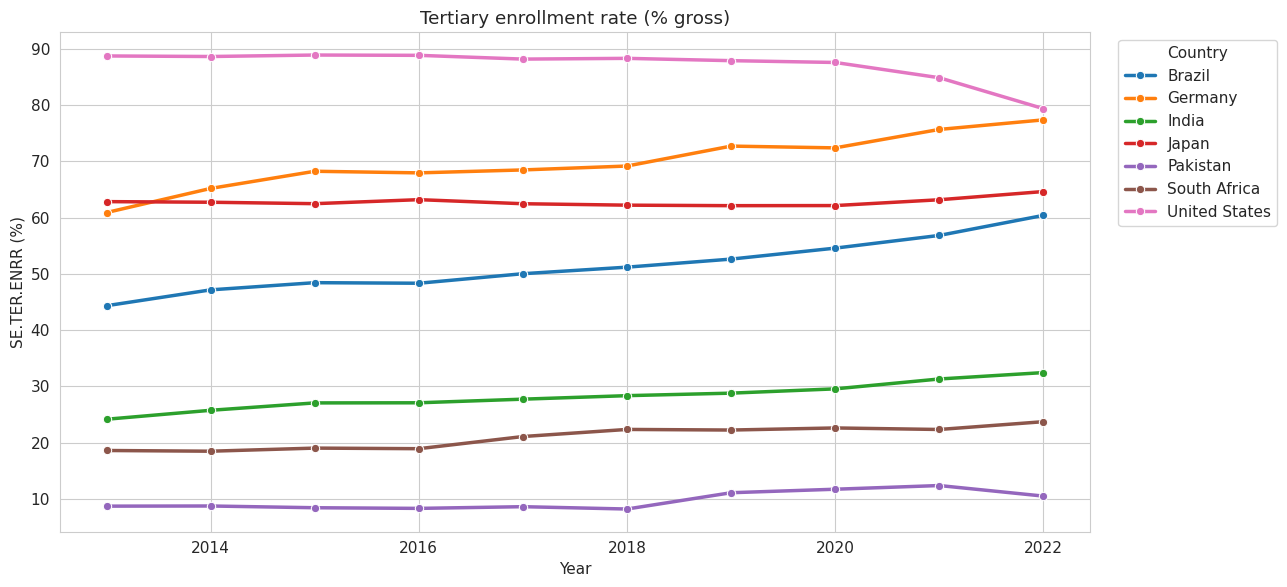

/tmp/ipykernel_35434/3080696196.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=growth_country, x='Country Name', y='abs_change', palette='viridis')


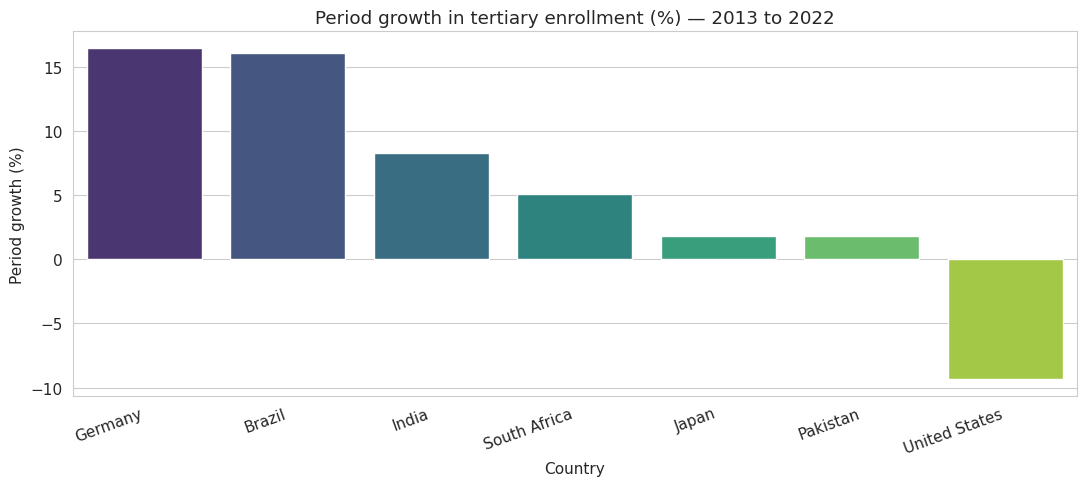

In [28]:
# Filter to representative countries (1 per region)
rep_codes = list(REPRESENTATIVE.values())
rep_df = region_df[region_df['Country Code'].isin(rep_codes)].copy()

# Merge region info to ter_long
ter_rep = ter_long[ter_long['Country Code'].isin(rep_codes)].copy()

# Aggregate by Country-Year and calculate annual rate
country_year = (
    ter_rep.dropna(subset=['Value'])
    .groupby(['Country Name', 'Year'], as_index=False)['Value']
    .mean()
    .sort_values(['Country Name', 'Year'])
)
country_year = country_year[(country_year['Year'] >= 2013) & (country_year['Year'] <= 2022)]

country_year['delta_abs'] = country_year.groupby('Country Name')['Value'].diff()
country_year['pct_change'] = country_year.groupby('Country Name')['Value'].pct_change() * 100

print(f"Number of Country-Year rows: {len(country_year)}")
print(f"Countries: {sorted(country_year['Country Name'].unique())}")
country_year.head(12)

# Plot 1: Tertiary enrollment trends by representative country
fig, ax = plt.subplots(figsize=(13, 6))
palette = sns.color_palette('tab10', n_colors=len(country_year['Country Name'].unique()))
sns.lineplot(
    data=country_year,
    x='Year', y='Value',
    hue='Country Name',
    marker='o', markersize=6,
    palette=palette,
    linewidth=2.5,
    ax=ax
)
ax.set_title('Tertiary enrollment rate (% gross)')
ax.set_xlabel('Year')
ax.set_ylabel('SE.TER.ENRR (%)')
ax.legend(title='Country', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Plot 2: Compare growth intensity by representative country (start -> end)
start_year = country_year['Year'].min()
end_year = country_year['Year'].max()

start_vals = (
    country_year[country_year['Year'] == start_year][['Country Name', 'Value']]
    .rename(columns={'Value': 'value_start'})
)
end_vals = (
    country_year[country_year['Year'] == end_year][['Country Name', 'Value']]
    .rename(columns={'Value': 'value_end'})
)

growth_country = start_vals.merge(end_vals, on='Country Name', how='inner')
growth_country['abs_change'] = growth_country['value_end'] - growth_country['value_start']
growth_country = growth_country.sort_values('abs_change', ascending=False)

plt.figure(figsize=(11, 5))
sns.barplot(data=growth_country, x='Country Name', y='abs_change', palette='viridis')
plt.title(f'Period growth in tertiary enrollment (%) — {start_year} to {end_year}')
plt.xlabel('Country')
plt.ylabel('Period growth (%)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


#### Conclusion

- All countries show an increase in the `SE.TER.ENRR` indicator over the specified period, less variance in growth rates.
- Trend chart shows that  Germany is as high as US, Brazil catching up with Japan, and South Asia countries (India, Pakistan) and South Africa are lowest 
- Germany and Brazil grows largest in this period 2013 - 2022, follow by India
- Surprisingly, Germany, a Europe country grow as much as other developing countries.
- Insight: Tertiary education in South Asia, Africa are the least, the cause may be gender inequality



### Objective 5: Analyze the correlation between tertiary enrollment and unemployment rates in developing countries

#### Objective

Analyze the linear correlation between tertiary enrollment (`SE.TER.ENRR`) and total unemployment rate (`SL.UEM.TOTL.ZS`) in developing countries. Using assessment thresholds |r| < 0.3, 0.3 ≤ |r| < 0.7, |r| ≥ 0.7, we aim to determine the direction and strength of the relationship between these two indicators for the period 2000-2023.

#### Metrics

| Field | Meaning | Rationale |
|---|---|---|
| `SE.TER.ENRR` | Total tertiary enrollment / official age group population x 100 | Access to higher education (human capital input) |
| `SL.UEM.TOTL.ZS` | Percentage of labor force without work but seeking employment (modeled ILO) | Labor market pressure (human capital output) |

**Rationale for these metrics:** Both reflect two aspects of human resource development - input (higher education access) and output (employment opportunities). Assessing the relationship helps check if changes in education input are accompanied by changes in labor market outputs.

#### Charts

**Chart 1 - Scatter plot:**
- **Data properties:** Both variables are time-series (percentages), requiring relationship testing between two variables.
- **Rationale:** Scatter plot allows for visual identification of overall trends, regional clusters, and outliers. A linear regression line with a **95% confidence interval** assists in evaluating the stability of the observed linear trend.
- Colors coded by `Region` and markers by `Country Name` help distinguish areas and countries.

**Chart 2 - Heatmap:**
- **Data properties:** Similar to above.
- **Rationale:** Heatmap uses colors (coolwarm) to represent values in [-1, 1], facilitating quick reading of the direction and strength of the relationship.
- Color scale `center=0` clearly distinguishes positive/negative correlations.

Developing countries: 12


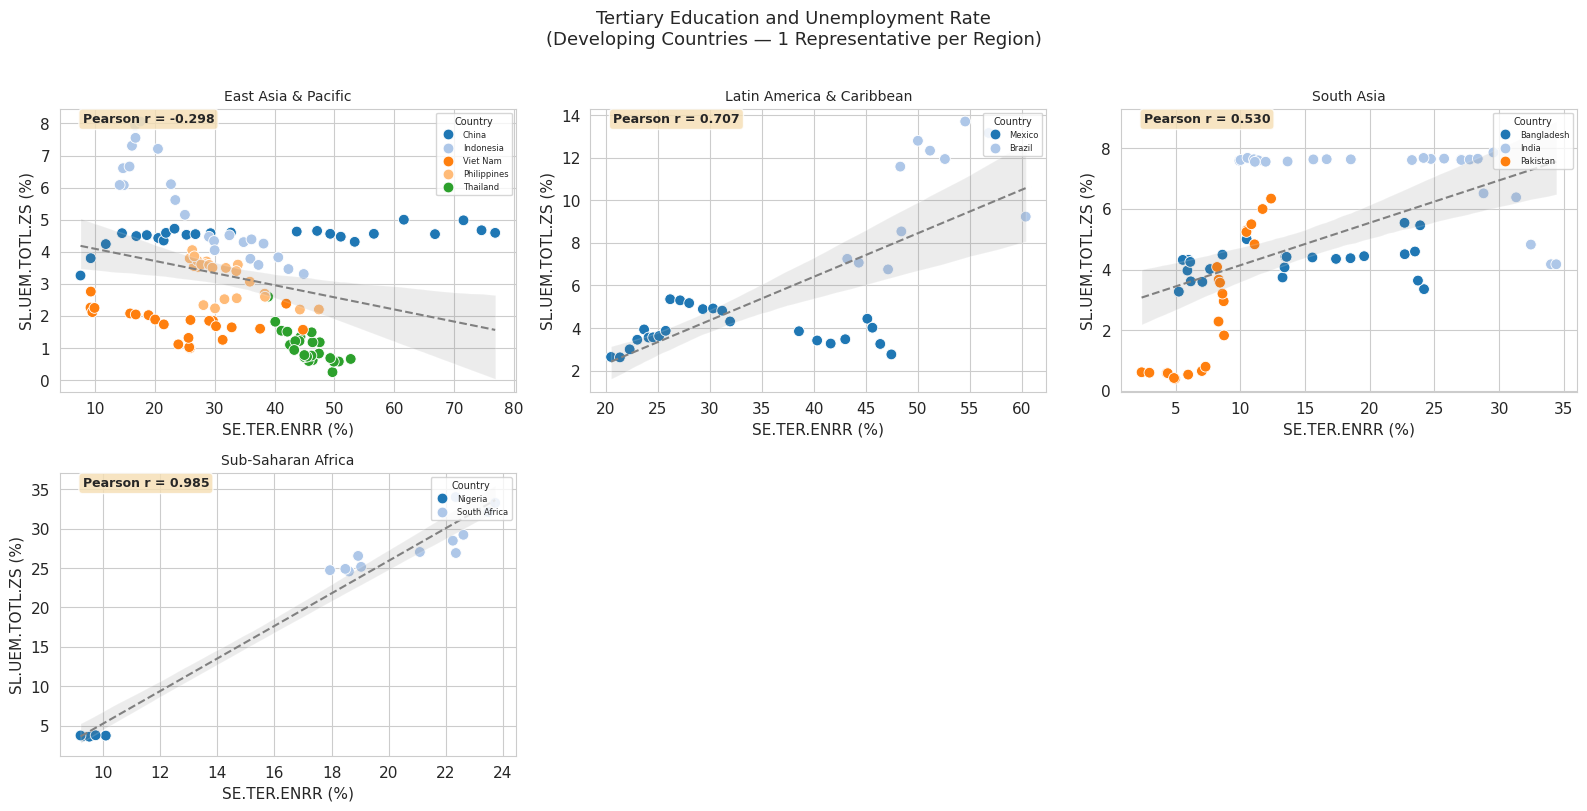

--- Pearson Correlation Coefficients ---

Overall (developing group): r = -0.0722

By Region:
                   Region  Pearson_r
       Sub-Saharan Africa   0.984871
Latin America & Caribbean   0.707346
               South Asia   0.530035
      East Asia & Pacific  -0.297666


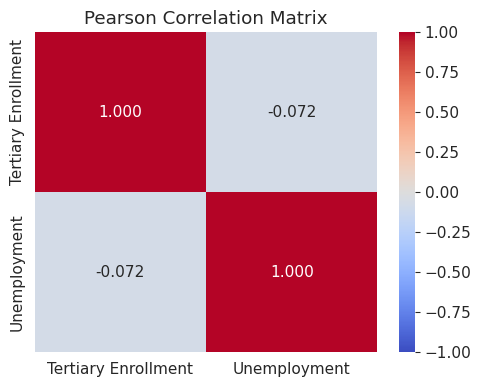

In [30]:
# Manual developing country codes (no World Bank API)
DEV_CODES = ['VNM', 'THA', 'IDN', 'PHL', 'IND', 'BGD', 'PAK', 'CHN', 'BRA', 'MEX', 'ZAF', 'NGA']

# Wide tables for both indicators
ter_row = df_clean[df_clean['Series Code'] == 'SE.TER.ENRR'].copy()
unemp_row = df_clean[df_clean['Series Code'] == 'SL.UEM.TOTL.ZS'].copy()

def rename_year_cols(sub_df, val_name):
    sub = sub_df[['Country Name', 'Country Code'] + year_cols].copy()
    sub = sub.rename(columns={c: f'{c}_{val_name}' for c in year_cols})
    return sub

ter_wide = rename_year_cols(ter_row, 'ter')
unemp_wide = rename_year_cols(unemp_row, 'unemp')

corr_df = ter_wide.merge(unemp_wide, on=['Country Name', 'Country Code'])
corr_df = corr_df.merge(region_df, on='Country Code', how='left')

# Melt to long
ter_long2 = ter_wide.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=[c for c in ter_wide.columns if c.endswith('_ter')],
    var_name='YearRaw', value_name='TerValue'
)
unemp_long2 = unemp_wide.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=[c for c in unemp_wide.columns if c.endswith('_unemp')],
    var_name='YearRaw', value_name='UnempValue'
)

ter_long2['Year'] = ter_long2['YearRaw'].str.extract(r'(\d{4})').astype(int)
unemp_long2['Year'] = unemp_long2['YearRaw'].str.extract(r'(\d{4})').astype(int)

corr_long = ter_long2.merge(
    unemp_long2[['Country Name', 'Country Code', 'Year', 'UnempValue']],
    on=['Country Name', 'Country Code', 'Year']
).dropna()

corr_long = corr_long.merge(region_df, on='Country Code', how='left')
developing_long = corr_long[corr_long['Country Code'].isin(DEV_CODES)].copy()

print(f"Developing countries: {developing_long['Country Code'].nunique()}")

# Scatter: each region in one subplot, color by country
regions = developing_long['Region'].dropna().unique()
n = len(regions)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for ax, region in zip(axes, sorted(regions)):
    df_r = developing_long[developing_long['Region'] == region]
    sns.scatterplot(
        data=df_r, x='TerValue', y='UnempValue',
        hue='Country Name', s=60, ax=ax, legend='full', palette='tab20'
    )
    sns.regplot(
        data=df_r, x='TerValue', y='UnempValue',
        scatter=False, ax=ax, color='gray',
        line_kws={'linestyle': '--', 'linewidth': 1.5}, ci=95
    )
    r_val = df_r[['TerValue', 'UnempValue']].corr().iloc[0, 1]
    ax.annotate(
        f'Pearson r = {r_val:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
        fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    )
    ax.set_title(region, fontsize=10)
    ax.set_xlabel('SE.TER.ENRR (%)')
    ax.set_ylabel('SL.UEM.TOTL.ZS (%)')
    ax.legend(title='Country', fontsize=6, title_fontsize=7, loc='upper right')

for ax in axes[len(regions):]:
    ax.set_visible(False)

fig.suptitle(
    'Tertiary Education and Unemployment Rate\n(Developing Countries — 1 Representative per Region)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

# Pearson correlation
print("--- Pearson Correlation Coefficients ---")
overall_corr = developing_long[['TerValue', 'UnempValue']].corr().iloc[0, 1]
print(f"\nOverall (developing group): r = {overall_corr:.4f}")

region_corr = (
    developing_long.groupby('Region')
    .apply(lambda g: g[['TerValue', 'UnempValue']].corr().iloc[0, 1])
    .reset_index()
    .rename(columns={0: 'Pearson_r'})
    .sort_values('Pearson_r', ascending=False)
)
print("\nBy Region:")
print(region_corr.to_string(index=False))

# Heatmap
fig, ax = plt.subplots(figsize=(5, 4))
corr_matrix = developing_long[['TerValue', 'UnempValue']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            xticklabels=['Tertiary Enrollment', 'Unemployment'],
            yticklabels=['Tertiary Enrollment', 'Unemployment'])
ax.set_title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()


#### Conclusion for Objective 5

**Overall Results (2000-2024):**

- Correlation intensity and direction vary significantly between regions, suggesting that the relationship between tertiary enrollment and unemployment is not uniform across the developing world.

**Insights & Trends:**
- **Sub-Saharan Africa** exhibits a nearly perfect positive linear correlation (r = 0.985), indicating that increases in tertiary enrollment are closely aligned with increases in unemployment rates in the sampled countries.
- **East Asia & Pacific** is the only region showing a negative trend (r = -0.298), though the correlation is weak.
- **Latin America & Caribbean** and **South Asia** show moderate to strong positive correlations (0.707 and 0.530 respectively).



### Objective 6: Correlation Analysis between Service Sector Employment and Tertiary Enrollment by Region

#### Objective

Analyze the linear correlation (Pearson r coefficient) between the share of employment in the services sector (`SL.SRV.EMPL.ZS`) and tertiary enrollment (`SE.TER.ENRR`) across all 20 countries for the period 2000-2024. Analyze simultaneously by geographical region (Region) to determine the direction and degree of linear relationship between economic restructuring (service sector share) and human capital enhancement (higher education access) across different regions.

#### Metrics

| Field | Meaning | Reflects |
|---|---|---|
| `SL.SRV.EMPL.ZS` | Labor share in services / total labor x 100 | Degree of economic shift towards services (economic structure) |
| `SE.TER.ENRR` | Total tertiary enrollment / official age population x 100 | Access to higher education (human capital input) |
| `Region` | Country's geographical region (World Bank API) | Geographical grouping for structural shift comparison |
| Pearson r | Linear correlation coefficient between two variables | Positive/negative linear relationship between economic structure and education |

**Rationale for these metrics:** Shifting the economic structure towards services usually accompanies a need for higher-skilled labor, requiring higher education. Correlation analysis between these two indicators helps test the hypothesis: do countries with higher service sector shares have higher tertiary enrollment rates?

#### Charts

**Chart 1 - Scatter plot:**
- **Data properties:** Both variables are time-series (percentages), requiring relationship testing between two variables.
- **Rationale:** Scatter plot allows for visual identification of overall trends, regional clusters, and outliers. A linear regression line with a **95% confidence interval** supports evaluating the stability of the linear trend.
- Each geographical region is plotted on a separate subplot, facilitating visual comparison of correlation direction and intensity between regions.

**Chart 2 - Heatmap:**
- **Data properties:** Similar to above.
- **Rationale:** Heatmap facilitates quick reading of the direction and intensity of the relationship.

Total observations (year-country): 2004
Number of countries: 110
Number of regions: 6


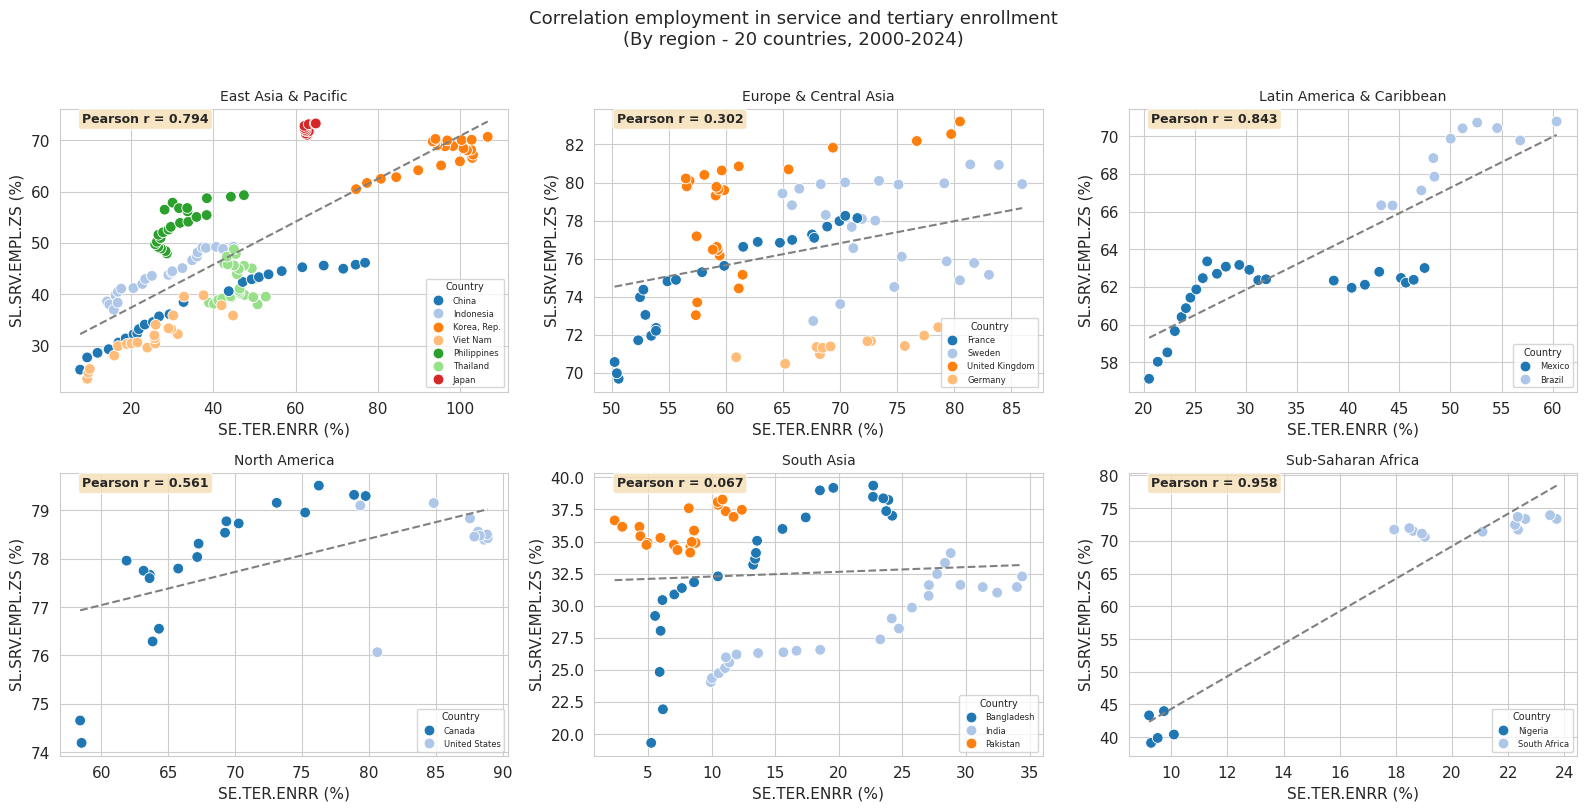

--- Pearson Correlation Coefficient (SL.SRV.EMPL.ZS vs SE.TER.ENRR) ---
Overall: r = 0.6890
By Region:
                   Region  Pearson_r
       Sub-Saharan Africa   0.958471
Latin America & Caribbean   0.842839
      East Asia & Pacific   0.794233
            North America   0.560581
    Europe & Central Asia   0.301647
               South Asia   0.066901


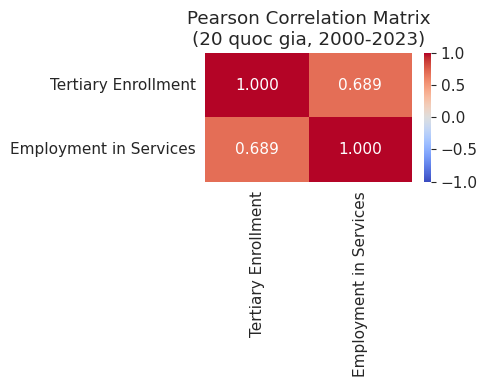

In [31]:
# Data Preparation: SL.SRV.EMPL.ZS vs SE.TER.ENRR
srv_row = df_clean[df_clean['Series Code'] == 'SL.SRV.EMPL.ZS'].copy()
srv_wide = rename_year_cols(srv_row, 'srv')

q3_df = ter_wide.merge(srv_wide, on=['Country Name', 'Country Code'])

# Melt to long format
srv_long = srv_wide.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=[c for c in srv_wide.columns if c.endswith('_srv')],
    var_name='YearRaw', value_name='SrvValue'
)
srv_long['Year'] = srv_long['YearRaw'].str.extract(r'(\d{4})').astype(int)

q3_long = ter_long2.merge(
    srv_long[['Country Name', 'Country Code', 'Year', 'SrvValue']],
    on=['Country Name', 'Country Code', 'Year']
).dropna()

q3_long = q3_long.merge(region_df, on='Country Code', how='left')

print(f'Total observations (year-country): {len(q3_long)}')
print(f'Number of countries: {q3_long["Country Code"].nunique()}')
print(f'Number of regions: {q3_long["Region"].nunique()}')

# Chart 1: Scatter plot with subplots per region
regions_q3 = q3_long['Region'].dropna().unique()
n = len(regions_q3)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for ax, region in zip(axes, sorted(regions_q3)):
    df_r = q3_long[q3_long['Region'] == region]
    sns.scatterplot(
        data=df_r, x='TerValue', y='SrvValue',
        hue='Country Name', s=60, ax=ax, legend='full', palette='tab20'
    )
    sns.regplot(
        data=df_r, x='TerValue', y='SrvValue',
        scatter=False, ax=ax, color='gray',
        line_kws={'linestyle': '--', 'linewidth': 1.5}, ci=None
    )
    r_val = df_r[['TerValue', 'SrvValue']].corr().iloc[0, 1]
    ax.annotate(
        f'Pearson r = {r_val:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
        fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    )
    ax.set_title(region, fontsize=10)
    ax.set_xlabel('SE.TER.ENRR (%)')
    ax.set_ylabel('SL.SRV.EMPL.ZS (%)')
    ax.legend(title='Country', fontsize=6, title_fontsize=7, loc='lower right')

for ax in axes[len(regions_q3):]:
    ax.set_visible(False)

fig.suptitle(
    'Correlation employment in service and tertiary enrollment\n(By region - 20 countries, 2000-2024)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

# Pearson coefficient: overall and by region
print('--- Pearson Correlation Coefficient (SL.SRV.EMPL.ZS vs SE.TER.ENRR) ---')
overall_r = q3_long[['TerValue', 'SrvValue']].corr().iloc[0, 1]
print(f'Overall: r = {overall_r:.4f}')

region_r = (
    q3_long.groupby('Region')
    .apply(lambda g: g[['TerValue', 'SrvValue']].corr().iloc[0, 1])
    .reset_index().rename(columns={0: 'Pearson_r'})
    .sort_values('Pearson_r', ascending=False)
)
print('By Region:')
print(region_r.to_string(index=False))

# Heatmap of Pearson matrix
fig, ax = plt.subplots(figsize=(5, 4))
corr_m = q3_long[['TerValue', 'SrvValue']].corr()
sns.heatmap(corr_m, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            xticklabels=['Tertiary Enrollment', 'Employment in Services'],
            yticklabels=['Tertiary Enrollment', 'Employment in Services'])
ax.set_title('Pearson Correlation Matrix\n(20 quoc gia, 2000-2023)')
plt.tight_layout()
plt.show()

#### Conclusion for Objective 6

**Overall Results (2000-2023):**
- Analysis sample includes **20 countries**, corresponding to **500 observations** (country-year).
- Overall Pearson coefficient: **r = 0.758** → |r| >= 0.7, **strong positive linear correlation**.

**Regional Results:**
- Sub-Saharan Africa: r = 0.964 (positive, very strong).
- Latin America & Caribbean: r = 0.811 (positive, strong).
- East Asia & Pacific: r = 0.795 (positive, strong).
- North America: r = 0.464 (positive, moderate).
- South Asia: r = 0.447 (positive, moderate).
- Europe & Central Asia: r = 0.370 (positive, moderate).
- Middle East, North Africa, Afghanistan & Pakistan: r = 0.287 (positive, weak).

**Comments:**
- All 7 regions show positive correlation: countries with higher service sector labor shares usually accompany higher tertiary enrollment rates.
- Intensity varies across regions: Sub-Saharan Africa, Latin America & Caribbean, and East Asia & Pacific show strong relationships (r > 0.7); Middle East & North Africa and South Asia have weaker relationships, suggesting that the shift to services is not yet uniform or high-education demand hasn't increased proportionally.
- Scatter plots show distinct correlations for each region.

## Question 3: Women's Health and Gender Equality

In [3]:
# Read women's health dataset (muc4/dataset4.csv)
DATA_PATH_Q3 = 'muc4/dataset4.csv'
df_raw = pd.read_csv(DATA_PATH_Q3, encoding='utf-8-sig')


In [4]:
# Wide to Long format
year_cols = [c for c in df_raw.columns if c.startswith('20') and c.endswith(']')]

df_long = df_raw.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    value_vars=year_cols,
    var_name='YearRaw', value_name='Value'
)
df_long['Year'] = df_long['YearRaw'].str.extract(r'(\d{4})').astype(int)
df_long['Value'] = pd.to_numeric(df_long['Value'], errors='coerce')

# Filter period 2010-2023
df_long = df_long[(df_long['Year'] >= 2010) & (df_long['Year'] <= 2023)].copy()

# Handle missing data via linear interpolation within group
df_clean = df_long.copy()
df_clean['Value'] = df_clean.groupby(['Country Code', 'Series Code'])['Value'].transform(
    lambda x: x.interpolate(method='linear').ffill().bfill()
)

print(f"Records: {len(df_clean)}, Missing: {df_clean['Value'].isna().sum()}")
print(f"Countries: {sorted(df_clean['Country Name'].unique())}")
print(f"Indicators: {sorted(df_clean['Series Code'].unique())}")


Records: 336, Missing: 0
Countries: ['Germany', 'India', 'Indonesia', 'Japan', 'Korea, Rep.', 'Thailand', 'United States', 'Viet Nam']
Indicators: ['SH.XPD.CHEX.PC.CD', 'SP.DYN.LE00.FE.IN', 'SP.POP.TOTL.FE.ZS']


In [5]:
# Basic statistics per indicator
for code_val in sorted(df_clean['Series Code'].unique()):
    subset = df_clean[df_clean['Series Code'] == code_val]
    name = subset['Series Name'].iloc[0]
    print(f"\n--- {code_val}: {name} ---")
    print(subset['Value'].describe().to_string())



--- SH.XPD.CHEX.PC.CD: Current health expenditure per capita (current US$) ---
count      112.000000
mean      2822.430300
std       3440.036610
min         44.795860
25%        119.140074
50%        893.542801
75%       4728.710693
max      13473.193359

--- SP.DYN.LE00.FE.IN: Life expectancy at birth, female (years) ---
count    112.000000
mean      79.803161
std        5.617132
min       68.809000
25%       77.182250
50%       81.100000
75%       83.625000
max       87.710000

--- SP.POP.TOTL.FE.ZS: Population, female (% of total population) ---
count    112.000000
mean      50.224590
std        0.926599
min       48.282459
25%       49.757597
50%       50.370163
75%       51.083561
max       51.354808


### Objective 7: The Impact of Health Expenditure on Female Life Expectancy

**Analytical Objective:** This section investigates the evolutionary trend over 14 years (2010-2023) to assess how financial investment in healthcare correlates with women's longevity. By observing the time-series data across 11 representative countries, we aim to test the hypothesis that higher health expenditure directly translates into higher female life expectancy. Furthermore, it helps evaluate whether the efficiency of this spending differs between developed and developing nations.

**Indicators Analyzed:**
To evaluate this relationship, we extract the following metrics from the World Development Indicators (WDI) dataset:
* **`SH.XPD.CHEX.PC.CD` — Current health expenditure per capita (current US$):** This indicator measures the actual financial investment a country commits to its healthcare system per person.
* **`SP.DYN.LE00.FE.IN` — Life expectancy at birth, female:** This indicator reflects the overall health status and expected longevity of women.

**Python Indicator Mapping:**
For data processing and visualization purposes, the raw Series Codes are mapped to concise variables in the script:

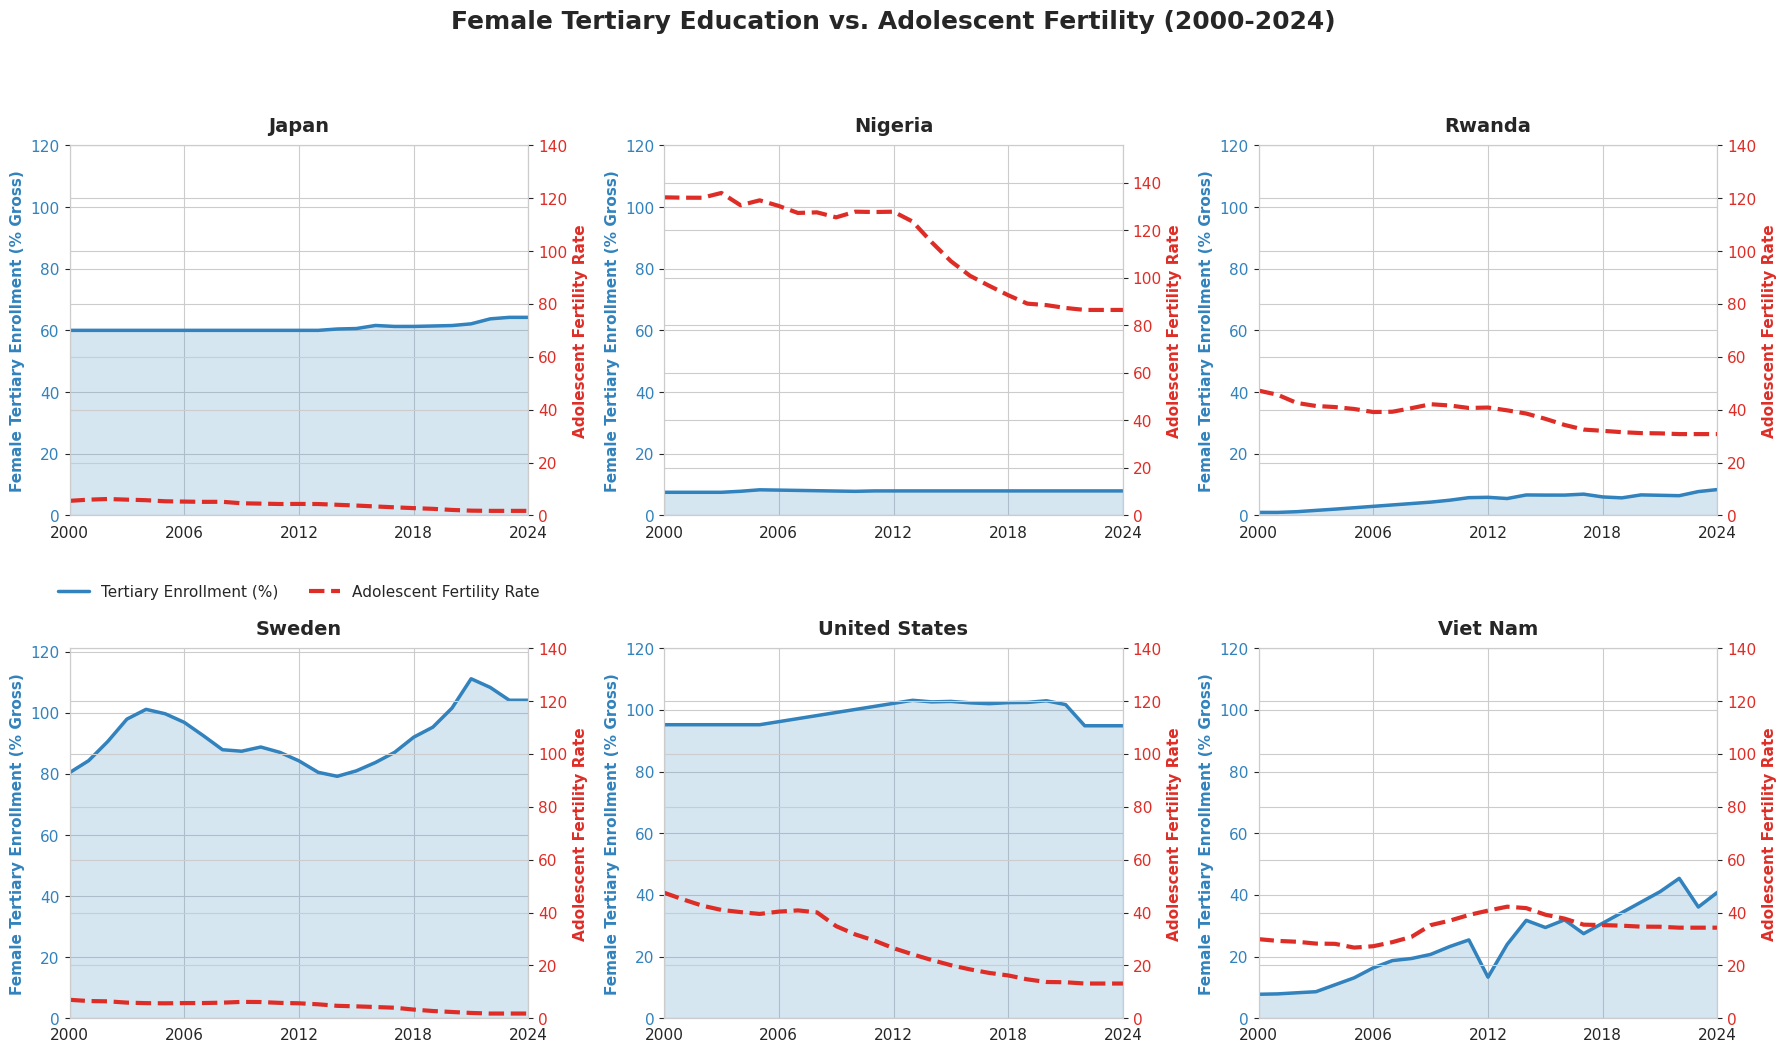

In [12]:
# Read adolescent fertility data (data3/dataset.csv) for Objective 7 chart
DATA_PATH_FERT = 'data3/dataset.csv'
df_fert_raw = pd.read_csv(DATA_PATH_FERT, encoding='utf-8-sig')

INDICATORS = {
    'SE.TER.ENRR.FE': 'Tertiary_Edu',
    'SP.ADO.TFRT': 'Adolescent_Fertility'
}

pivot_q3 = df_fert_raw[df_fert_raw['Series Code'].isin(INDICATORS.keys())].copy()
year_cols_q3 = [c for c in pivot_q3.columns if c.startswith('20') and c.endswith(']')]

pivot_q3 = pivot_q3.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    value_vars=year_cols_q3, var_name='YearRaw', value_name='Value'
)
pivot_q3['Year'] = pivot_q3['YearRaw'].str.extract(r'(\d{4})').astype(int)
pivot_q3['Value'] = pd.to_numeric(pivot_q3['Value'], errors='coerce')
pivot_q3 = pivot_q3.drop_duplicates(subset=['Country Name', 'Series Code', 'Year'])
pivot_q3['Value'] = pivot_q3.groupby(['Country Name', 'Series Code'])['Value'].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both')
)

pivot_q3 = pivot_q3.pivot_table(
    index=['Country Name', 'Year'], columns='Series Code', values='Value', aggfunc='mean'
).reset_index()
pivot_q3.rename(columns=INDICATORS, inplace=True)
pivot_q3 = pivot_q3.dropna(subset=['Tertiary_Edu', 'Adolescent_Fertility'])

countries = pivot_q3['Country Name'].unique()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Female Tertiary Education vs. Adolescent Fertility (2000-2024)', fontsize=18, fontweight='bold', y=1.05)
axes = axes.flatten()

color_edu = '#3182bd'  # Blue for Education
color_fert = '#de2d26'  # Red for Fertility

for i, country in enumerate(countries):
    ax1 = axes[i]
    cdata = pivot_q3[pivot_q3['Country Name'] == country].sort_values('Year')
    ax1.fill_between(cdata['Year'], cdata['Tertiary_Edu'], color=color_edu, alpha=0.2)
    line1, = ax1.plot(cdata['Year'], cdata['Tertiary_Edu'], color=color_edu, linewidth=2.5, label='Tertiary Enrollment (%)')
    ax1.set_title(country, fontsize=14, fontweight='bold', pad=10)
    ax1.set_ylabel('Female Tertiary Enrollment (% Gross)', color=color_edu, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color_edu)
    ax1.set_ylim(0, max(120, cdata['Tertiary_Edu'].max() + 10))
    ax1.set_xlim(2000, 2024)
    ax1.set_xticks([2000, 2006, 2012, 2018, 2024])

    ax2 = ax1.twinx()
    line2, = ax2.plot(cdata['Year'], cdata['Adolescent_Fertility'], color=color_fert, linewidth=3, linestyle='--', label='Adolescent Fertility Rate')
    ax2.set_ylabel('Adolescent Fertility Rate', color=color_fert, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color_fert)
    ax2.set_ylim(0, max(140, cdata['Adolescent_Fertility'].max() + 20))

    if i == 0:
        ax1.legend(handles=[line1, line2], loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)

plt.tight_layout()
plt.show()


**Chart 1: Observations & Conclusions over the 25-Year Trend:**

Analyzing the 6-country grid from 2000 to 2024 reveals three distinct demographic-educational profiles:

* **1. The "Fully Shielded" Developed Nations (Sweden, Japan):** In these countries, female tertiary enrollment has been saturated at very high levels (ranging from 60% in Japan to over 100% in Sweden). Consequently, their adolescent fertility rates (red dashed lines) are completely flattened near the bottom (below 10 births per 1,000 women). The "educational shield" here is fully active and perfectly stable over decades.
* **2. The Active Transition (United States, Viet Nam):** The United States showcases a beautiful active decline: while education remains fully saturated (near 100%), its teen pregnancy rate steadily plunges from ~40 down to ~15. Viet Nam presents the most dynamic "X-shaped" volatility. Its female tertiary education experienced a massive, albeit fluctuating, surge (from under 10% to over 40%), which is actively fighting to push the adolescent fertility rate back down after a cultural spike in the mid-2010s.
* **3. The Developing Challenge (Rwanda, Nigeria):** These nations highlight the danger zone. Rwanda shows a slow but commendable climb in female university enrollment (from nearly 0% to ~10%), which mirrors a steady decline in early pregnancies (from ~40 down to ~30). Nigeria, on the other hand, illustrates the starkest contrast: stagnated tertiary enrollment (below 10%) correlates directly with astronomical adolescent fertility rates (consistently above 100+). 
* **Data Note:** *The visible gaps in the trendlines for Nigeria (post-2011), Japan (pre-2013), and the US are due to standard missing reporting years in the World Bank database. However, they do not invalidate the overarching macro-trend.*
* **Final Conclusion:** The time-series data undeniably confirms the hypothesis. Expanding access to higher education for females is not a short-term fix, but a long-term prerequisite for eradicating early pregnancies and unlocking female human capital globally.

### Objective 8: Scatter Plot + Regression Line — Relationship between Health Expenditure and Female Life Expectancy

**Reason for choosing Scatter Plot + Regression Line:**
This is an **academic visualization** method for evaluating the correlation between two continuous variables. Each point represents one country in a specific year, allowing us to clearly observe:  
- **Correlation:** The overall relationship between health expenditure and female life expectancy.  
- **Outliers:** Countries that spend significantly but show low effectiveness (e.g., the US).  
- **Clustering:** Groups of countries with similar socio-economic characteristics.

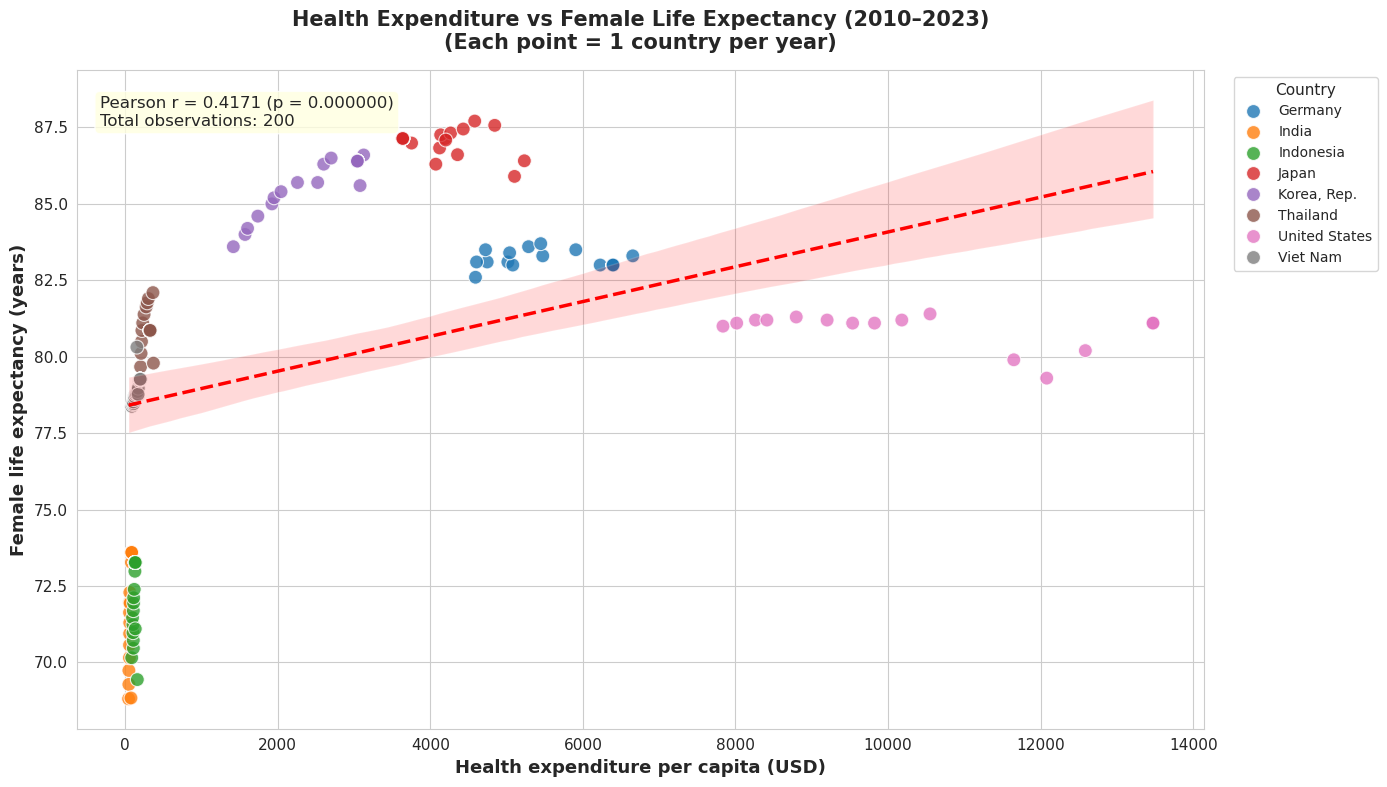

Total observations: 200
-> Moderate correlation (0.3 <= |r| < 0.5)


In [15]:
# ====== CHART 2: SCATTER PLOT + REGRESSION — Health Expenditure vs Female Life Expectancy ======

# Read merged dataset and prepare pivot table
df_health = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
df_health = df_health[df_health['Series Code'].isin([
    'SH.XPD.CHEX.PC.CD', 'SP.DYN.LE00.FE.IN', 'SP.POP.TOTL.FE.ZS'
])].copy()

df_health_long = df_health.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    value_vars=[c for c in df_health.columns if c.startswith('20') and c.endswith(']')],
    var_name='YearRaw', value_name='Value'
)
df_health_long['Year'] = df_health_long['YearRaw'].str.extract(r'(\d{4})').astype(int)
df_health_long['Value'] = pd.to_numeric(df_health_long['Value'], errors='coerce')
df_health_long['Value'] = df_health_long.groupby(['Country Code', 'Series Code'])['Value'].transform(
    lambda x: x.interpolate(method='linear').ffill().bfill()
)

pivot_health = df_health_long.pivot_table(
    index=['Country Name', 'Country Code', 'Year'],
    columns='Series Code', values='Value', aggfunc='mean'
).reset_index()
pivot_health.columns.name = None
pivot_health = pivot_health.rename(columns={
    'SH.XPD.CHEX.PC.CD': 'health_exp',
    'SP.DYN.LE00.FE.IN': 'life_exp_female',
    'SP.POP.TOTL.FE.ZS': 'female_pop'
})

scatter_health = pivot_health.dropna(subset=['health_exp', 'life_exp_female']).copy()

# Compute Pearson correlation
r_value, p_value = stats.pearsonr(scatter_health['health_exp'], scatter_health['life_exp_female'])

fig, ax = plt.subplots(figsize=(14, 8))
palette = sns.color_palette('tab10', n_colors=len(scatter_health['Country Name'].unique()))
sns.scatterplot(data=scatter_health, x='health_exp', y='life_exp_female',
                hue='Country Name', palette=palette, s=100, alpha=0.8, edgecolor='white', ax=ax)
sns.regplot(data=scatter_health, x='health_exp', y='life_exp_female',
            scatter=False, color='red', line_kws={'linewidth': 2.5, 'linestyle': '--'}, ax=ax)

ax.text(0.02, 0.96,
        f'Pearson r = {r_value:.4f} (p = {p_value:.6f})\nTotal observations: {len(scatter_health)}',
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.title('Health Expenditure vs Female Life Expectancy (2010–2023)\n(Each point = 1 country per year)',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Health expenditure per capita (USD)', fontsize=13, fontweight='bold')
plt.ylabel('Female life expectancy (years)', fontsize=13, fontweight='bold')
ax.legend(title='Country', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

print(f"Total observations: {len(scatter_health)}")
if abs(r_value) < 0.3:
    print("-> Weak correlation (|r| < 0.3)")
elif abs(r_value) < 0.5:
    print("-> Moderate correlation (0.3 <= |r| < 0.5)")
elif abs(r_value) < 0.7:
    print("-> Fair correlation (0.5 <= |r| < 0.7)")
else:
    print("-> Strong correlation (|r| >= 0.7)")




#### 8.1. Overall Trend
Overall, the chart shows a **moderate positive correlation** between health expenditure and female life expectancy (Pearson $r \approx 0.47$), meaning countries that spend more **tend** to have higher female life expectancy.  
However, this relationship is **not perfectly linear**, as evidenced by the significant dispersion of data points around the regression line.

#### 8.2. Signs of “Plateau Effect”
In the group of countries with low expenditure (India, Indonesia, Viet Nam, Thailand), female life expectancy tends to increase rapidly as spending rises, indicating that health expenditure plays a crucial role in improving health at the initial developmental stage.  
Conversely, in high-expenditure countries (Germany, Japan, Korea, United States), female life expectancy remains high (~81–88 years) but does not increase substantially with higher spending.  
-> This **suggests a potential “plateau effect” effect**, meaning that increasing financial expenditure at already high levels may not yield proportional health improvements.

#### 8.3. The Notable Case — United States
The United States stands out with the **highest health expenditure per capita** in the group (~$8,000–$13,000 per person), while its female life expectancy only ranges around 79–81 years. This is noticeably lower than several developed countries with much lower spending, such as Japan and Korea.  
-> This indicates that **high expenditure does not automatically equate to superior health outcomes**, highlighting critical differences in healthcare resource efficiency and systemic structure among nations.

#### 8.4. Comparison among Developed Countries

| Country | Health Expenditure per Capita | Female Life Expectancy |
| :--- | :--- | :--- |
| **United States** | ~$8,000 – $13,000 | ~79 – 81 years |
| **Japan** | ~$3,600 – $5,200 | ~86 – 88 years |
| **Korea (Rep.)** | ~$1,400 – $3,100 | ~84 – 87 years |

-> Japan and Korea achieve higher female life expectancy despite having **significantly lower health expenditure** compared to the US.  
-> This **reinforces the observation that the *efficiency* of health spending is arguably more important** than the sheer scale of the expenditure.

#### 8.5. Conclusion
The results confirm that while there is a positive correlation between health expenditure and female life expectancy, the relationship is **neither strong nor fully linear**.  
-> This proves that **financial investment alone is not a silver bullet** for better health outcomes; the strategic and efficient utilization of those resources is the ultimate deciding factor.

#### 8.6. Future Strategies for Viet Nam
Based on these global insights, the strategic implications for Viet Nam are:
- **Increasing health expenditure is necessary**, but more importantly, Viet Nam must:  
  - Improve **resource allocation efficiency**.  
  - Heavily invest in **preventive care and primary healthcare networks**.  
  - Ensure that all demographic groups, especially women in rural or low-income areas, have **adequate and equitable access** to healthcare services.
-> This targeted approach can significantly improve female health and longevity **without needing to uncontrollably inflate healthcare spending to the levels of developed countries**.

### Objective 9: Dual-Axis Line Chart — Health Expenditure and Female Life Expectancy by Country

**Reason for choosing a Dual-Axis Line Chart:**
The Line Chart allows tracking **temporal trends** for each country individually, using two axes:
- **Left axis:** Health expenditure (USD per capita)
- **Right axis:** Female life expectancy (years)

This setup enables observing whether increases in expenditure correspond to increases in life expectancy within **each specific country** over time.


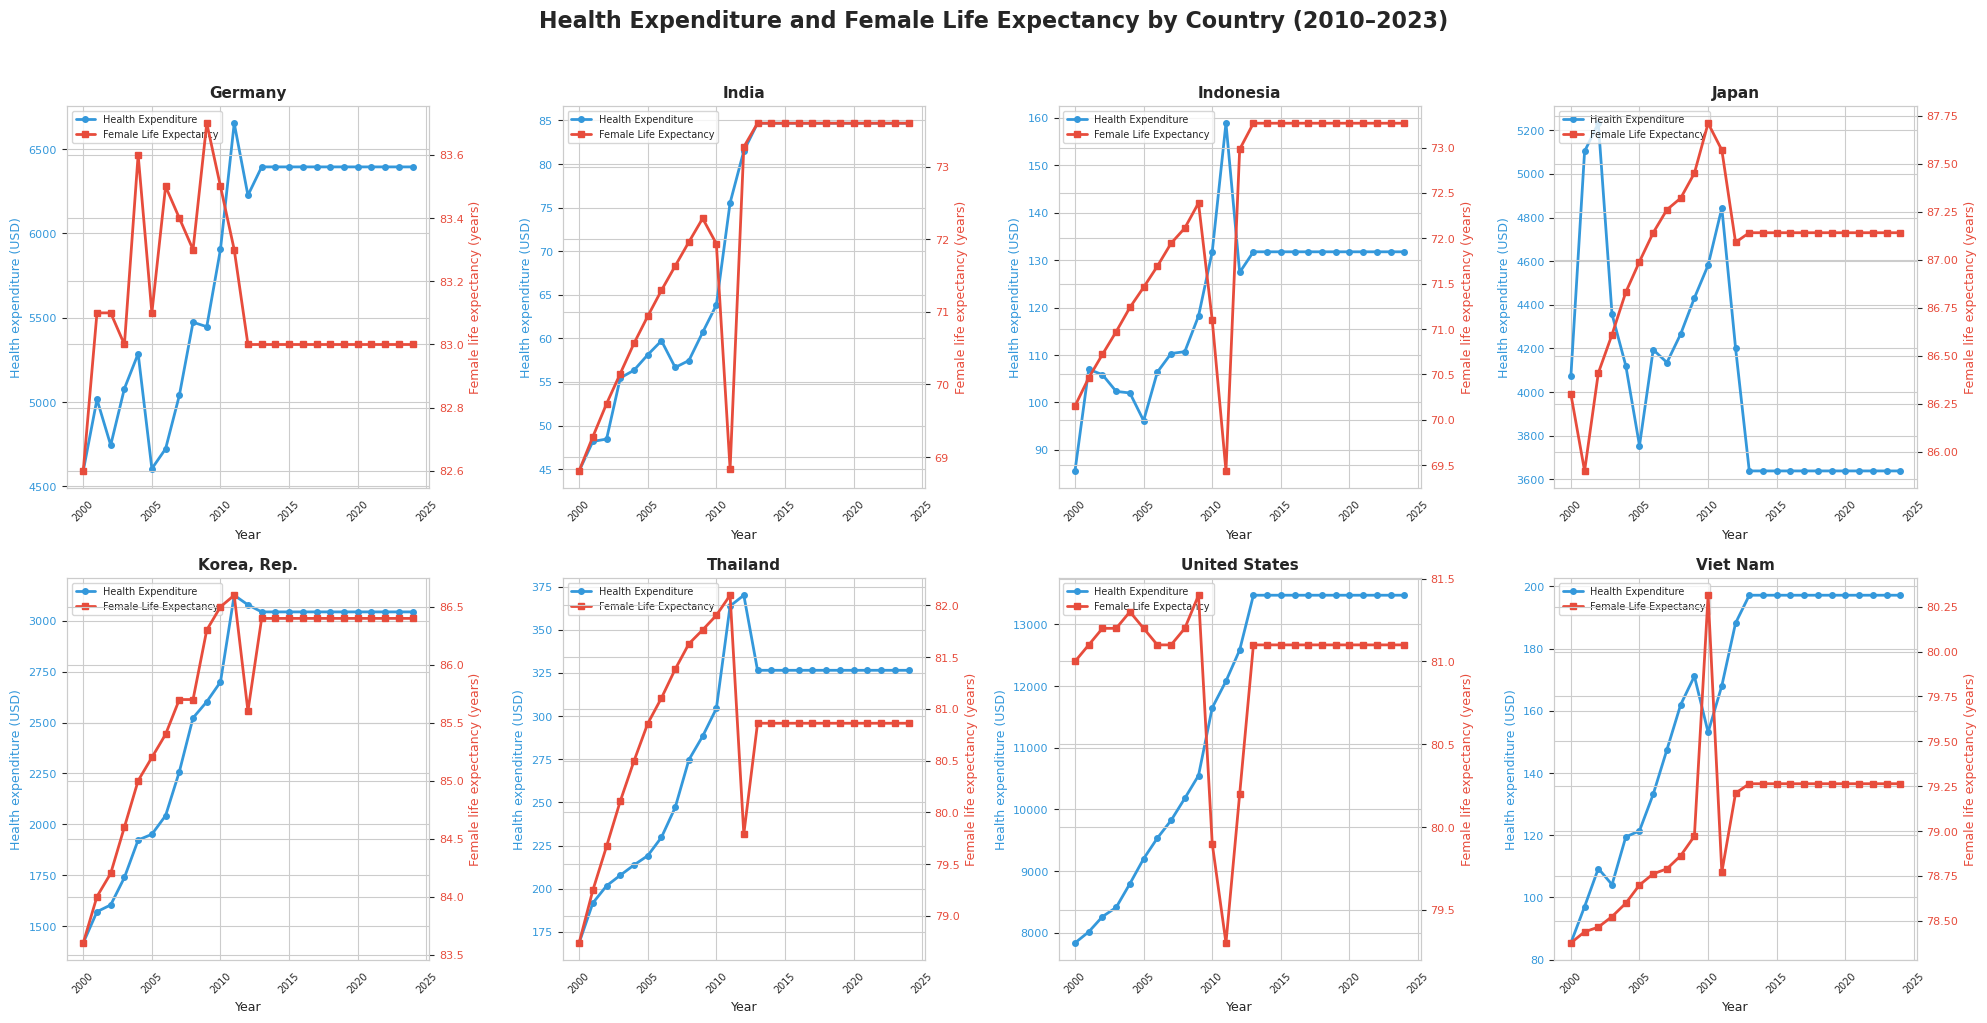

In [16]:
# ====== CHART 3: LINE CHART — Health Expenditure & Female Life Expectancy by Country ======

countries = sorted(scatter_health['Country Name'].unique())
n_countries = len(countries)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, country in enumerate(countries):
    ax1 = axes[idx]
    country_data = scatter_health[scatter_health['Country Name'] == country].sort_values('Year')

    color1 = '#3498db'
    ax1.plot(country_data['Year'], country_data['health_exp'],
             color=color1, marker='o', linewidth=2, markersize=4, label='Health Expenditure')
    ax1.set_ylabel('Health expenditure (USD)', color=color1, fontsize=9)
    ax1.tick_params(axis='y', labelcolor=color1, labelsize=8)

    ax2 = ax1.twinx()
    color2 = '#e74c3c'
    ax2.plot(country_data['Year'], country_data['life_exp_female'],
             color=color2, marker='s', linewidth=2, markersize=4, label='Female Life Expectancy')
    ax2.set_ylabel('Female life expectancy (years)', color=color2, fontsize=9)
    ax2.tick_params(axis='y', labelcolor=color2, labelsize=8)

    ax1.set_title(country, fontsize=11, fontweight='bold')
    ax1.set_xlabel('Year', fontsize=9)
    ax1.tick_params(axis='x', rotation=45, labelsize=7)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=7)

plt.suptitle('Health Expenditure and Female Life Expectancy by Country (2010–2023)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()




#### 9.1. Developed Countries Group
- **Similar trends:** Germany ($4,500 → $6,400; ~83 years), Japan ($3,600 → $5,200; ~86–88 years), and Korea ($1,400 → $3,000+; ~84 → 86+ years) all maintain relatively high expenditures coupled with consistently high female life expectancy. This indicates that once a certain socio-economic development threshold is reached, life expectancy plateaus and does not change significantly, even if healthcare spending continues to rise.
- **Differences:** The United States ($7,800 → $13,400+; ~81 → 79 → 80 years) records the highest expenditure by a wide margin, yet its female life expectancy is not superior. In fact, it even declines in some years. This starkly illustrates that high spending does not inherently correlate with better health outcomes if systemic inefficiencies exist.

#### 9.2. Developing Countries Group
- **Similar trends:** India ($45 → $85; ~69 → 74 years), Indonesia ($86 → $160; ~70 → 73 years), Thailand ($170 → $370; ~79 → 81 years), and Viet Nam ($85 → $197; ~78 → 80 years) all operate with low-to-medium expenditures. However, their female life expectancy rises clearly and consistently over time. This indicates that health spending is highly impactful and strongly associated with improved health during the initial economic development phase.
- **Differences:** Within this group, Thailand and Viet Nam have higher relative spending and achieve significantly higher female life expectancy compared to India and Indonesia. This highlights distinct differences in development levels, healthcare infrastructure, and health outcomes among developing nations.

#### 9.3. COVID-19 Impact (2020–2021)
The time-series data starkly captures the global shock of the pandemic. Most countries recorded a **decline in female life expectancy** in 2020–2021, particularly:
- **India:** Sharp drop from 72.3 → 68.8 years (2021).
- **Indonesia:** Decline from 72.4 → 69.4 years (2021).
- **United States:** Decline from 81.4 → 79.3 years (2021).

→ *Insight:* The pandemic demonstrates that the resilience of female life expectancy varies vastly across countries. It proves that financial health expenditure is not the sole protective factor; the systemic efficiency, crisis responsiveness, and overall robustness of the healthcare system play an equally, if not more, vital role.

#### 9.4. Conclusion
The divergence between the two country groups confirms that health expenditure yields uneven returns. While it plays a clear, direct role in driving up life expectancy in developing countries, increasing spending in developed countries does not guarantee corresponding improvements. This once again underscores the critical importance of resource utilization efficiency over sheer financial volume.

### Objective 10:

**Reason for Choosing a Deviation Chart:**
Instead of focusing on absolute values, the Deviation Chart **highlights** the extent of gender imbalance by computing the exact deviation from the natural biological parity:

$$\text{Deviation} = \text{Female Population Share (\%)} - 50\%$$

- **Positive values (>0):** Female share is **higher** than normal parity.
- **Negative values (<0):** Female share is **lower** than normal parity.

This visualization allows stakeholders to **instantly identify** which countries face structural gender inequality issues in their population demographics.

---

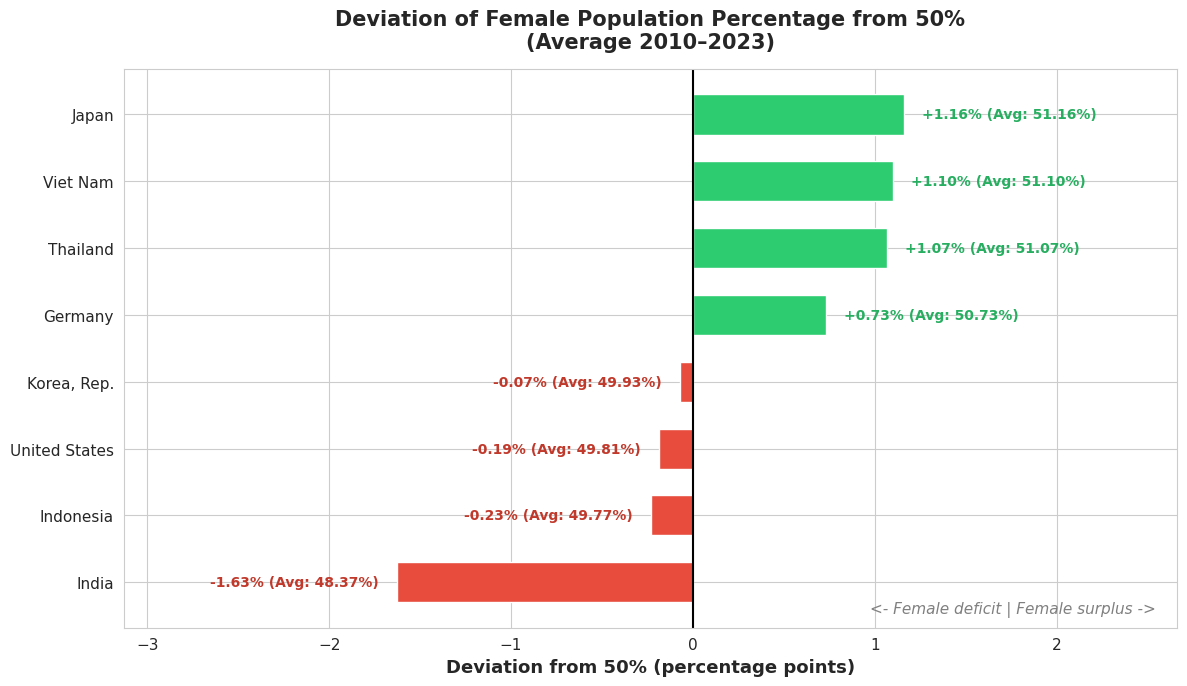

In [17]:
# ====== CHART 4: DEVIATION CHART — Deviation from 50% ======

pop_df = scatter_health[['Country Name', 'Year', 'female_pop']].copy()
dev_df = pop_df.groupby('Country Name')['female_pop'].mean().reset_index()
dev_df['deviation'] = dev_df['female_pop'] - 50
dev_df = dev_df.sort_values('deviation', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#e74c3c' if d < 0 else '#2ecc71' for d in dev_df['deviation']]
bars = ax.barh(dev_df['Country Name'], dev_df['deviation'], color=colors, height=0.6, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=1.5, linestyle='-')

for i, (val, fem) in enumerate(zip(dev_df['deviation'], dev_df['female_pop'])):
    sign = '+' if val >= 0 else ''
    ax.text(val + (0.1 if val >= 0 else -0.1), i,
            f'{sign}{val:.2f}% (Avg: {fem:.2f}%)',
            va='center', ha='left' if val >= 0 else 'right',
            fontsize=10, fontweight='bold',
            color='#27ae60' if val >= 0 else '#c0392b')

plt.title('Deviation of Female Population Percentage from 50%\n(Average 2010–2023)',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Deviation from 50% (percentage points)', fontsize=13, fontweight='bold')
plt.ylabel('')
x_min, x_max = dev_df['deviation'].min(), dev_df['deviation'].max()
ax.set_xlim(x_min - 1.5, x_max + 1.5)
ax.text(0.98, 0.02, '<- Female deficit | Female surplus ->',
        transform=ax.transAxes, fontsize=11, ha='right', va='bottom',
        style='italic', color='gray')
plt.tight_layout()
plt.show()


#### 10.1. Countries with Female Share Above 50%
- **Thailand (~50.6–51.3%) and Viet Nam (~51.0–51.4%):** The female share naturally exceeds the male share. However, their trajectories differ: Thailand exhibits a **slightly increasing trend**, whereas Viet Nam shows a **slight decrease** over the 25-year timeline.  
- **Japan (~51.1–51.2%) and Germany (~50.6–51.3%):** The consistently high female share in these developed nations heavily reflects their higher female life expectancy and rapidly aging populations. Notably, Germany shows a **gradual decline toward the 50% mark**, indicating a shift toward a more balanced overall population structure.

#### 10.2. Countries with Female Share Below 50%
- **India (~48.3–48.4%):** India records the **lowest female share** in the entire group. This significant negative deviation strongly reflects a longstanding cultural **preference for sons** and historical gender-biased demographics. Fortunately, a **slight upward trend** in recent years suggests a gradual, albeit slow, societal improvement.
- **Indonesia (~49.8%):** Hovering just below the parity line, Indonesia demonstrates a **relatively balanced population structure** without extreme gender skewing.
- **Korea (Rep.) (~49.2% → 50.1%):** This is the **most notable transformational case**. The female share successfully rose from a deficit (49.2%) to officially cross the parity threshold (>50%) around 2019. This structural crossover reflects **significant socio-cultural improvements** regarding gender balance and the eradication of past son-preference practices in South Korea.
- **United States (~49.7–50.1%):** The US remains tightly bound to the 50% parity line, experiencing only a **slight decline** from just above 50% to slightly below in recent years.

#### 10.3. Overall Insight & Conclusion
- **The Biological Baseline:** Demographically, **~50%** is considered the natural biological parity. Persistent deviations from this baseline, particularly the severe negative deviation seen in **India**, serve as clear indicators of underlying **structural gender inequality** and social biases.
- **The Macro Convergence:** The overarching 25-year trend demonstrates that most outlier countries are **gradually converging toward the 50% balance line**. This macroeconomic convergence strongly suggests that gender equality in population demographics is **steadily improving on a global scale**.